# Implementing Deep Q-Learning

In [1]:
import gymnasium as gym

env = gym.make("CartPole-v1")
input_shape = env.observation_space.shape
n_outputs = env.action_space.n

print("Input shape:", input_shape)
print("input shape:", n_outputs)

Input shape: (4,)
input shape: 2


In [2]:
import tensorflow as tf

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Dense(
            32,
            activation="selu",
            kernel_initializer="lecun_normal",
            input_shape=input_shape,
        ),
        tf.keras.layers.Dense(32, activation="selu", kernel_initializer="lecun_normal"),
        tf.keras.layers.Dense(n_outputs),
    ]
)
target = tf.keras.models.clone_model(model)
target.set_weights(model.get_weights())

2023-09-16 10:25:38.303928: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-09-16 10:25:39.892616: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-09-16 10:25:39.919603: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-09-16 10:25:39.919794: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so retur

In [3]:
import numpy as np


def epsilon_greedy_policy(model: tf.keras.Model, state: int, eps: float = 0) -> int:
    return (
        np.random.randint(2)
        if np.random.rand() < eps
        else np.argmax(model.predict(state[np.newaxis])[0])
    )

In [4]:
import collections

replay_buffer = collections.deque(maxlen=2000)
replay_buffer

deque([], maxlen=2000)

In [5]:
from typing import Deque, List, Tuple

from numpy.typing import NDArray


def sample_experiences(
    replay_buffer: Deque[Tuple[NDArray, int, float, NDArray, bool]], batch_size: int
) -> Tuple[List[NDArray], List[int], List[int], List[NDArray], List[bool]]:
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[idx] for idx in indices]
    states, actions, rewards, next_states, terminated = [
        np.array(field) for field in zip(*batch)
    ]

    return states, actions, rewards, next_states, terminated


def play_one_step(
    env: gym.Env,
    model: tf.keras.Model,
    state: NDArray,
    eps: float,
    replay_buffer: collections.deque,
) -> None:
    action = epsilon_greedy_policy(model=model, state=state, eps=eps)
    next_state, reward, terminated, truncated, info = env.step(action)
    replay_buffer.append([state, action, reward, next_state, terminated])

    return next_state, reward, terminated, truncated, info


def train_one_step(
    model: tf.keras.Model,
    target: tf.keras.Model,
    replay_buffer: collections.deque,
    batch_size: int,
    discount_factor: float,
    optimizer: tf.optimizers.Optimizer,
    loss_fn: tf.losses.Loss,
) -> None:
    states, actions, rewards, states_next, terminated = sample_experiences(
        replay_buffer=replay_buffer, batch_size=batch_size
    )
    actions_next_best = np.argmax(model.predict(states_next), axis=1)
    q_values_next_best = np.take_along_axis(
        target.predict(states_next), actions_next_best, axis=1
    )
    q_values_target = rewards + (1 - terminated) * discount_factor * q_values_next_best

    mask = tf.one_hot(actions, model.output_shape[-1])
    with tf.GradientTape() as tape:
        q_values_actual = model(states)
        q_values_actual = tf.reduce_sum(q_values_actual * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(q_values_actual, q_values_target))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

In [6]:
batch_size = 32
discount_factor = 0.95
optimizer = tf.optimizers.Adam(learning_rate=1e-3)
loss_fn = tf.losses.mse

total_rewards = []

for episode in range(600):
    state, info = env.reset()
    eps = max(1 - episode / 500, 0.01)

    total_reward = 0

    for step in range(200):
        next_state, reward, terminated, truncated, info = play_one_step(
            env=env, model=model, state=state, eps=eps, replay_buffer=replay_buffer
        )
        total_reward += reward
        if terminated:
            break

    total_rewards.append(total_reward)

    if episode >= 50:
        train_one_step(
            model=model,
            target=target,
            replay_buffer=replay_buffer,
            batch_size=batch_size,
            discount_factor=discount_factor,
            optimizer=optimizer,
            loss_fn=loss_fn,
        )

    if episode % 50 == 0:
        target.set_weights(model.get_weights())

1/1 [==============================] - 0s 34ms/step


ValueError: `indices` and `arr` must have the same number of dimensions

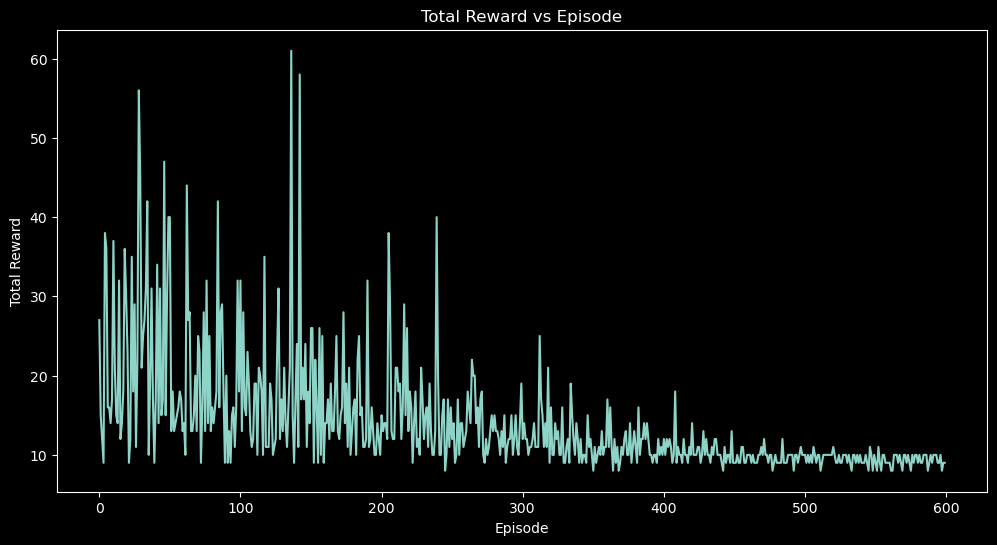

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(total_rewards)
ax.set(xlabel="Episode", ylabel="Total Reward", title="Total Reward vs Episode")
plt.show()